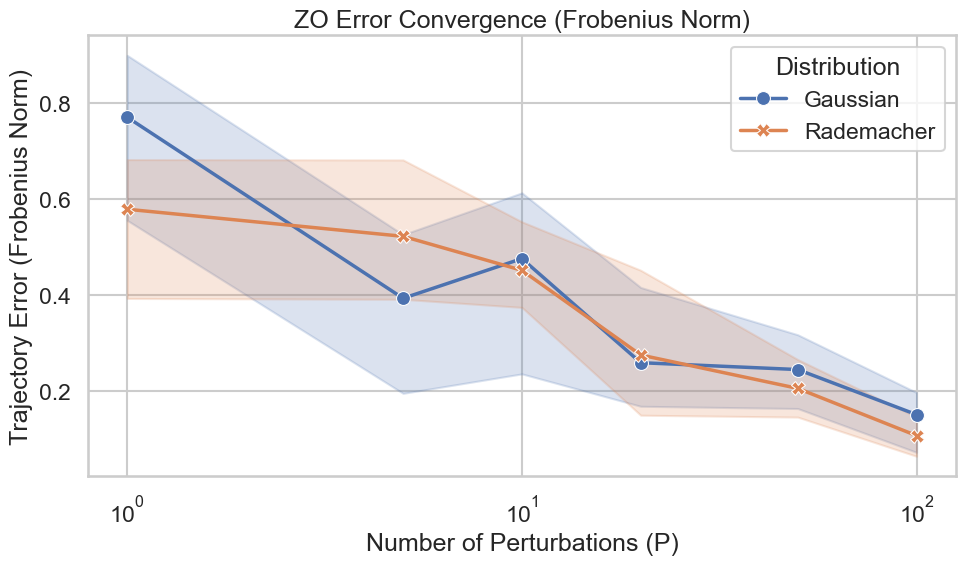

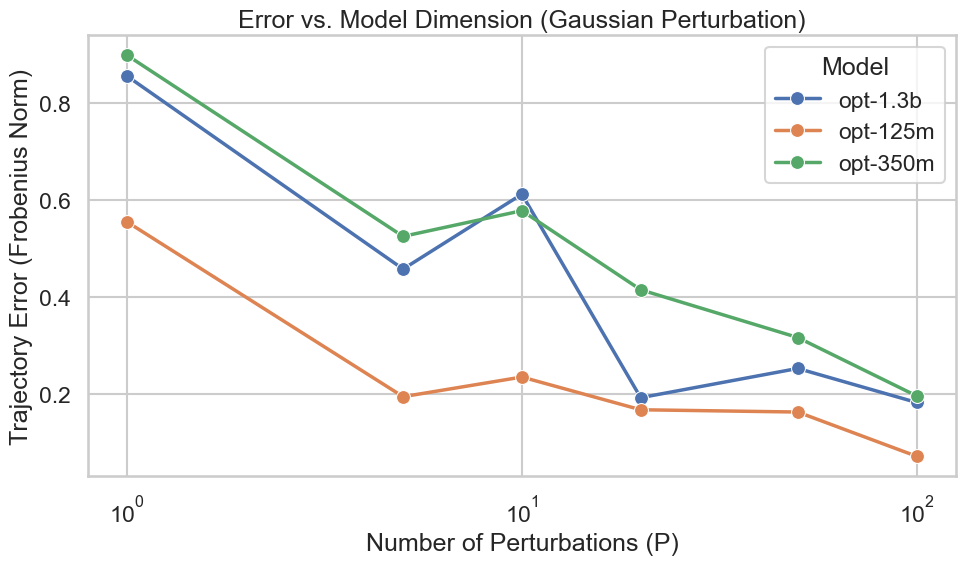

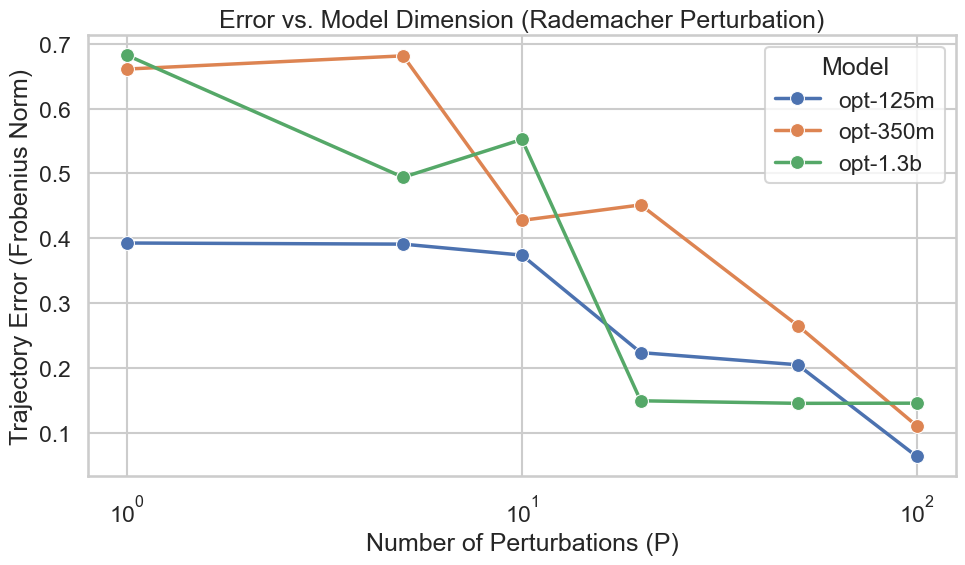

In [ ]:
import json
import glob
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


def find_data_dir():
    for parent in (Path.cwd(), *Path.cwd().parents):
        candidate = parent / "llm_results"
        if candidate.is_dir():
            return candidate
    raise FileNotFoundError(
        f"Could not find an 'llm_results' directory from {Path.cwd()}"
    )


DATA_DIR = find_data_dir()


def calculate_frobenius_norm(sgd_history, zo_history):
    sgd = np.array(sgd_history)
    zo = np.array(zo_history)
    min_len = min(len(sgd), len(zo))
    sgd = sgd[:min_len]
    zo = zo[:min_len]
    return np.linalg.norm(sgd - zo, ord="fro")


def parse_and_load_data():
    files = glob.glob(str(DATA_DIR / "*.json"))
    data_list = []

    for f in files:
        try:
            name_no_ext = os.path.splitext(os.path.basename(f))[0]
            parts = name_no_ext.split("_")
            k = int(parts[-1])
            dist_type = parts[-2]
            model_name = "_".join(parts[:-2])

            with open(f, "r") as file:
                content = json.load(file)

            samples = content.get("samples", [])
            file_errors = []

            for s in samples:
                if "sgd_probs_history" in s and "zo_probs_history" in s:
                    err = calculate_frobenius_norm(
                        s["sgd_probs_history"], s["zo_probs_history"]
                    )
                    file_errors.append(err)

            if file_errors:
                avg_error = np.mean(file_errors)
                data_list.append(
                    {
                        "Model": model_name,
                        "Distribution": dist_type,
                        "Perturbation Size (k)": k,
                        "Frobenius Norm Error": avg_error,
                    }
                )

        except Exception as e:
            print(f"Error processing {f}: {e}")

    return pd.DataFrame(data_list)


def plot_results(df):
    if df.empty:
        print("No data loaded!")
        return

    df = df.copy()

    df["Distribution"] = df["Distribution"].replace(
        {
            "bernoulli": "Rademacher",
            "gaussian": "Gaussian",
        }
    )
    df["Model"] = df["Model"].str.replace("llm_results/", "", regex=False)
    sns.set(style="whitegrid", context="talk")

    plt.figure(figsize=(10, 6))
    sns.lineplot(
        data=df,
        x="Perturbation Size (k)",
        y="Frobenius Norm Error",
        hue="Distribution",
        style="Distribution",
        markers=True,
        dashes=False,
        linewidth=2.5,
        markersize=10,
    )
    plt.xscale("log")
    plt.title("ZO Error Convergence (Frobenius Norm)")
    plt.ylabel("Trajectory Error (Frobenius Norm)")
    plt.xlabel("Number of Perturbations (P)")
    plt.tight_layout()
    plt.savefig("figures/frobenius_hint1_hint3.pdf", bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(10, 6))
    gaussian_subset = df[df["Distribution"] == "Gaussian"]

    if not gaussian_subset.empty:
        sns.lineplot(
            data=gaussian_subset,
            x="Perturbation Size (k)",
            y="Frobenius Norm Error",
            hue="Model",
            marker="o",
            linewidth=2.5,
            markersize=10,
        )
        plt.xscale("log")
        plt.title("Error vs. Model Dimension (Gaussian Perturbation)")
        plt.ylabel("Trajectory Error (Frobenius Norm)")
        plt.xlabel("Number of Perturbations (P)")
        plt.tight_layout()
        plt.savefig(
            "figures/frobenius_hint2_dimension_gaussian.pdf", bbox_inches="tight"
        )
        plt.show()

    plt.figure(figsize=(10, 6))
    rademacher_subset = df[df["Distribution"] == "Rademacher"]

    if not rademacher_subset.empty:
        sns.lineplot(
            data=rademacher_subset,
            x="Perturbation Size (k)",
            y="Frobenius Norm Error",
            hue="Model",
            marker="o",
            linewidth=2.5,
            markersize=10,
        )
        plt.xscale("log")
        plt.title("Error vs. Model Dimension (Rademacher Perturbation)")
        plt.ylabel("Trajectory Error (Frobenius Norm)")
        plt.xlabel("Number of Perturbations (P)")
        plt.tight_layout()
        # plt.savefig("figures/frobenius_hint2_dimension_rademacher.pdf", bbox_inches="tight")
        plt.show()


if __name__ == "__main__":
    df = parse_and_load_data()
    plot_results(df)

In [ ]:
import json
import glob
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

K_VALUES_TO_PLOT = [1, 5, 10, 20, 50, 100]
CLASS_IDX = 1


def find_data_dir():
    for parent in (Path.cwd(), *Path.cwd().parents):
        candidate = parent / "llm_results"
        if candidate.is_dir():
            return candidate
    raise FileNotFoundError(
        f"Could not find an 'llm_results' directory from {Path.cwd()}"
    )


DATA_DIR = find_data_dir()
colors = {
    "SGD": "#2d3436",
    "Gaussian": "#0984e3",
    "Rademacher": "#d63031",
}


def get_file_path(model, dist, k):
    return os.path.join(DATA_DIR, f"{model}_{dist}_{k}.json")


def get_num_samples(model):
    for k in [100, 50, 20, 10, 5, 1]:
        for dist in ["gaussian", "bernoulli"]:
            path = get_file_path(model, dist, k)
            if os.path.exists(path):
                with open(path, "r") as f:
                    data = json.load(f)
                    return len(data.get("samples", []))
    return 1


def plot_model_trajectories(model_name):
    num_samples = get_num_samples(model_name)
    print(f"Found {num_samples} samples for model {model_name}")

    for sample_idx in range(num_samples):
        fig, axes = plt.subplots(2, 3, figsize=(18, 9), sharex=True, sharey=True)
        axes = axes.flatten()

        for i, k in enumerate(K_VALUES_TO_PLOT):
            ax = axes[i]
            handles = []
            labels = []

            # --- dummy handle for P value in legend ---
            p_handle = Line2D([], [], color="none", label=rf"$\mathbf{{P={k}}}$")
            handles.append(p_handle)
            labels.append(rf"$P={k}$")

            for dist in ["gaussian", "bernoulli"]:
                path = get_file_path(model_name, dist, k)
                if os.path.exists(path):
                    with open(path, "r") as f:
                        data = json.load(f)
                        if sample_idx < len(data.get("samples", [])):
                            sample = data["samples"][sample_idx]

                            # ZO trajectory
                            if "zo_probs_history" in sample:
                                zo_traj = np.array(sample["zo_probs_history"])[
                                    :, CLASS_IDX
                                ]
                                style = "--" if dist == "gaussian" else ":"
                                label_text = (
                                    f"ZO SGD ({dist.capitalize()})"
                                    if dist != "bernoulli"
                                    else "ZO SGD (Rademacher)"
                                )
                                (h,) = ax.plot(
                                    zo_traj,
                                    linestyle=style,
                                    linewidth=2.5,
                                    color=colors[
                                        (
                                            dist.capitalize()
                                            if dist != "bernoulli"
                                            else "Rademacher"
                                        )
                                    ],
                                    alpha=0.9,
                                    label=label_text,
                                )
                                handles.append(h)
                                labels.append(label_text)

                            # SGD trajectory (only once per subplot)
                            if "sgd_probs_history" in sample and all(
                                l != "FO SGD" for l in labels
                            ):
                                sgd_traj = np.array(sample["sgd_probs_history"])[
                                    :, CLASS_IDX
                                ]
                                (h,) = ax.plot(
                                    sgd_traj,
                                    linestyle="-",
                                    linewidth=3.0,
                                    color=colors["SGD"],
                                    alpha=0.6,
                                    label="FO SGD",
                                )
                                handles.append(h)
                                labels.append("FO SGD")

            # Axes styling
            ax.set_ylim(0.0, 1.0)
            ax.grid(True, linestyle=":", alpha=0.6)
            if i >= 3:
                ax.set_xlabel("Iterations")
            if i % 3 == 0:
                ax.set_ylabel("Predicted Probability")

            # Legend
            ax.legend(handles, labels, loc="lower right", fontsize=11, frameon=True)

        fig.suptitle(
            f"ZO Trajectory Convergence: {model_name.upper()} + SST2 (Sample {sample_idx})",
            fontsize=22,
            y=0.97,
        )

        plt.tight_layout()
        plt.savefig(
            f"figures/trajectory_grid_{model_name}_sample{sample_idx}.pdf",
            bbox_inches="tight",
        )
        plt.close()


def main():
    plot_model_trajectories("opt-350m")


if __name__ == "__main__":
    main()

Found 5 samples for model opt-350m


In [ ]:
import json
import glob
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

K_VALUES_TO_PLOT = [1, 5, 10, 20, 50, 100]
CLASS_IDX = 1


def find_data_dir():
    for parent in (Path.cwd(), *Path.cwd().parents):
        candidate = parent / "llm_results"
        if candidate.is_dir():
            return candidate
    raise FileNotFoundError(
        f"Could not find an 'llm_results' directory from {Path.cwd()}"
    )


DATA_DIR = find_data_dir()


def get_file_path(model, dist, k):
    return os.path.join(DATA_DIR, f"{model}_{dist}_{k}.json")


def find_representative_sample_idx(model):
    ref_path = get_file_path(model, "gaussian", 100)

    if not os.path.exists(ref_path):
        for k in [100, 50, 20, 10, 5, 1]:
            for d in ["gaussian", "bernoulli"]:
                p = get_file_path(model, d, k)
                if os.path.exists(p):
                    ref_path = p
                    break

    try:
        with open(ref_path, "r") as f:
            data = json.load(f)

        max_range = -1
        best_idx = 0

        for i, sample in enumerate(data.get("samples", [2])):
            if "sgd_probs_history" in sample:
                probs = np.array(sample["sgd_probs_history"])
                if probs.shape[1] > CLASS_IDX:
                    probs_c = probs[:, CLASS_IDX]
                    prob_range = np.max(probs_c) - np.min(probs_c)
                    if prob_range > max_range:
                        max_range = prob_range
                        best_idx = i
        return best_idx

    except Exception as e:
        print(f"Error searching sample: {e}")
        return 0


def plot_model_trajectories(model_name):
    sample_idx = find_representative_sample_idx(model_name)

    fig, axes = plt.subplots(2, 3, figsize=(18, 9), sharex=True, sharey=True)
    axes = axes.flatten()

    colors = {
        "SGD": "#000000",  # black
        "Gaussian": "#0057B8",  # deep blue
        "Rademacher": "#C1121F",  # deep red
    }

    markers = {
        "SGD": "o",
        "Gaussian": "^",
        "Rademacher": "s",
    }

    for i, k in enumerate(K_VALUES_TO_PLOT):
        ax = axes[i]

        path_g = get_file_path(model_name, "gaussian", k)
        path_b = get_file_path(model_name, "bernoulli", k)

        handles = []
        labels = []

        # ===== Dummy handle for MODEL NAME =====
        model_handle = Line2D([], [], color="none", label=f"{model_name.upper()}")
        handles.append(model_handle)
        labels.append(f"{model_name.upper()}")

        # ===== Dummy handle for P =====
        p_handle = Line2D([], [], color="none", label=rf"$\mathbf{{P={k}}}$")
        handles.append(p_handle)
        labels.append(rf"$P={k}$")

        # ===== Gaussian =====
        if os.path.exists(path_g):
            with open(path_g, "r") as f:
                data = json.load(f)
                if len(data["samples"]) > sample_idx:
                    s = data["samples"][sample_idx]

                    zo_traj = np.array(s["zo_probs_history"])[:, CLASS_IDX]
                    (h1,) = ax.plot(
                        zo_traj,
                        linestyle="--",
                        linewidth=5,
                        color=colors["Gaussian"],
                        alpha=1,
                        marker=markers["Gaussian"],
                        markersize=8,
                        markevery=20,
                        label="ZO SGD (Gaussian)",
                    )
                    handles.append(h1)
                    labels.append("ZO SGD (Gaussian)")

                    sgd_traj = np.array(s["sgd_probs_history"])[:, CLASS_IDX]
                    (h2,) = ax.plot(
                        sgd_traj,
                        linestyle="-",
                        linewidth=5,
                        color=colors["SGD"],
                        alpha=0.6,
                        marker=markers["SGD"],
                        markersize=8,
                        markevery=20,
                        label="FO SGD",
                    )
                    handles.append(h2)
                    labels.append("FO SGD")

        # ===== Rademacher =====
        if os.path.exists(path_b):
            with open(path_b, "r") as f:
                data = json.load(f)
                if len(data["samples"]) > sample_idx:
                    s = data["samples"][sample_idx]

                    zo_traj = np.array(s["zo_probs_history"])[:, CLASS_IDX]
                    (h3,) = ax.plot(
                        zo_traj,
                        linestyle=":",
                        linewidth=5,
                        color=colors["Rademacher"],
                        alpha=1,
                        marker=markers["Rademacher"],
                        markersize=8,
                        markevery=20,
                        label="ZO SGD (Rademacher)",
                    )
                    handles.append(h3)
                    labels.append("ZO SGD (Rademacher)")

        # ===== Axes styling =====
        ax.set_ylim(0, 1)
        ax.grid(True, linestyle=":", alpha=0.6)

        if i >= 3:
            ax.set_xlabel("Iterations")
        if i % 3 == 0:
            ax.set_ylabel("Predicted Probability")

        ax.legend(
            handles,
            labels,
            # loc="upper right",
            fontsize=14,
            frameon=True,
        )

    fig.suptitle(
        f"ZO Trajectory Convergence: {model_name.upper()} + SST2",
        fontsize=22,
        y=0.97,
    )

    plt.tight_layout()
    plt.savefig(f"figures/trajectory_grid_{model_name}.pdf", bbox_inches="tight")
    plt.close()


def main():
    plot_model_trajectories("opt-1.3b")


if __name__ == "__main__":
    main()

In [ ]:
import json
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

K_VALUES_TO_PLOT = [1, 5, 10, 20, 50, 100]
CLASS_IDX = 1
MODELS = ["opt-125m", "opt-350m", "opt-1.3b"]


def find_data_dir():
    for parent in (Path.cwd(), *Path.cwd().parents):
        candidate = parent / "llm_results"
        if candidate.is_dir():
            return candidate
    raise FileNotFoundError(
        f"Could not find an 'llm_results' directory from {Path.cwd()}"
    )


DATA_DIR = find_data_dir()


def get_file_path(model, dist, k):
    return os.path.join(DATA_DIR, f"{model}_{dist}_{k}.json")


def find_representative_sample_idx(model):
    ref_path = get_file_path(model, "gaussian", 100)

    if not os.path.exists(ref_path):
        for k in [100, 50, 20, 10, 5, 1]:
            for d in ["gaussian", "bernoulli"]:
                p = get_file_path(model, d, k)
                if os.path.exists(p):
                    ref_path = p
                    break

    try:
        with open(ref_path, "r") as f:
            data = json.load(f)

        max_range = -1
        best_idx = 0
        for i, sample in enumerate(data.get("samples", [])):
            if "sgd_probs_history" in sample:
                probs = np.array(sample["sgd_probs_history"])
                if probs.shape[1] > CLASS_IDX:
                    probs_c = probs[:, CLASS_IDX]
                    prob_range = np.max(probs_c) - np.min(probs_c)
                    if prob_range > max_range:
                        max_range = prob_range
                        best_idx = i
        return best_idx

    except Exception as e:
        print(f"Error searching sample: {e}")
        return 0


def plot_all_models():
    fig, axes = plt.subplots(3, 6, figsize=(24, 8), sharex=True, sharey=True)
    axes = axes.flatten()

    colors = {
        "SGD": "#000000",  # black
        "Gaussian": "#0057B8",  # deep blue
        "Rademacher": "#C1121F",  # deep red
    }

    markers = {
        "SGD": "o",
        "Gaussian": "^",
        "Rademacher": "s",
    }

    for row_idx, model_name in enumerate(MODELS):
        sample_idx = find_representative_sample_idx(model_name)

        for col_idx, k in enumerate(K_VALUES_TO_PLOT):
            ax_idx = row_idx * 6 + col_idx
            ax = axes[ax_idx]

            path_g = get_file_path(model_name, "gaussian", k)
            path_b = get_file_path(model_name, "bernoulli", k)

            handles = []
            labels = []

            # ===== Dummy handle for MODEL NAME =====
            model_handle = Line2D([], [], color="none", label=f"{model_name.upper()}")
            handles.append(model_handle)
            labels.append(f"{model_name.upper()}")

            # ===== Gaussian =====
            if os.path.exists(path_g):
                with open(path_g, "r") as f:
                    data = json.load(f)
                    if len(data["samples"]) > sample_idx:
                        s = data["samples"][sample_idx]

                        zo_traj = np.array(s["zo_probs_history"])[:, CLASS_IDX]
                        (h1,) = ax.plot(
                            zo_traj,
                            linestyle="--",
                            linewidth=3,
                            color=colors["Gaussian"],
                            alpha=1,
                            marker=markers["Gaussian"],
                            markersize=6,
                            markevery=20,
                            label="ZO SGD (Gaus.)",
                        )
                        handles.append(h1)
                        labels.append("ZO SGD (Gaus.)")

                        sgd_traj = np.array(s["sgd_probs_history"])[:, CLASS_IDX]
                        (h2,) = ax.plot(
                            sgd_traj,
                            linestyle="-",
                            linewidth=3,
                            color=colors["SGD"],
                            alpha=0.6,
                            marker=markers["SGD"],
                            markersize=6,
                            markevery=20,
                            label="FO SGD",
                        )
                        handles.append(h2)
                        labels.append("FO SGD")

            # ===== Rademacher =====
            if os.path.exists(path_b):
                with open(path_b, "r") as f:
                    data = json.load(f)
                    if len(data["samples"]) > sample_idx:
                        s = data["samples"][sample_idx]

                        zo_traj = np.array(s["zo_probs_history"])[:, CLASS_IDX]
                        (h3,) = ax.plot(
                            zo_traj,
                            linestyle=":",
                            linewidth=3,
                            color=colors["Rademacher"],
                            alpha=1,
                            marker=markers["Rademacher"],
                            markersize=6,
                            markevery=20,
                            label="ZO SGD (Rade.)",
                        )
                        handles.append(h3)
                        labels.append("ZO SGD (Rade.)")

            ax.set_ylim(0, 1)
            ax.grid(True, linestyle=":", alpha=0.6)

            if row_idx == 0:
                ax.set_title(f"P={k}", fontsize=20, fontweight="bold")
            if row_idx == 2:
                ax.set_xlabel("Iterations", fontsize=15)
            if col_idx == 0:
                ax.set_ylabel("Predicted Probability", fontsize=15)

            ax.legend(handles, labels, fontsize=13, frameon=True)

    # fig.suptitle("ZO Trajectory Convergence for Different Models + SST2", fontsize=22, y=0.97)
    plt.tight_layout()
    plt.savefig("figures/trajectory_all_models.pdf", bbox_inches="tight")
    plt.close()


def main():
    plot_all_models()


if __name__ == "__main__":
    main()